# 🚇 BTS/MRT Travel Time Prediction — Custom ML Model

**Project:** BTS/MRT Ridership Analytics Pipeline  
**Author:** Chayakorn Phuttharak

---

## เป้าหมาย

ทำนายว่า **"ถ้าออกจากสถานี A ไปสถานี B ตอน X โมง วันที่ Y จะใช้เวลากี่นาที"** เฉพาะระบบรถไฟฟ้า BTS/MRT

## Pipeline

```
1. Generate synthetic data (10,000+ rows)
   ├─ Base travel time จาก OSRM (ระยะทางจริง)
   └─ ปรับตาม rush hour / weekend / rainy season pattern

2. Feature Engineering
   ├─ Time features: hour, day_of_week, is_weekend, is_holiday, month
   ├─ Route features: line, distance_km, num_interchanges
   └─ Environmental: is_rainy_season

3. Train Multiple Models
   ├─ Baseline: Linear Regression
   ├─ Random Forest
   └─ XGBoost (expected best)

4. Evaluate & Compare
   └─ MAE, RMSE, R² score

5. Save Model
   └─ joblib.dump() → .pkl file for deployment
```

---

**Target:** predicted travel time (minutes)  
**Features:** station pair, time, day, weather condition


## Section 0: Setup

In [ ]:
!pip install xgboost scikit-learn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print("Libraries loaded")


Libraries loaded


---

## Section 1: Generate Synthetic Data

### สร้างข้อมูล travel time จำลองที่สมจริง

**Rules ที่ใช้จำลอง (อ้างอิงจาก real-world Bangkok transit pattern):**

1. **Base travel time** = distance_km × 2.5 นาที/กม. (ความเร็วเฉลี่ย BTS/MRT ~24 km/h)
2. **Rush hour penalty** (7-9am, 5-7pm): +20-35% จากเวลาปกติ
3. **Weekend discount**: -10-15% (ผู้โดยสารน้อย ไม่ต้องรอนาน)
4. **Interchange penalty**: +3 นาที ต่อการเปลี่ยนสาย
5. **Rainy season** (พ.ค.-ต.ค.): +5-10% (คนใช้รถไฟฟ้าเยอะขึ้นเพราะเลี่ยงฝน)
6. **Holiday**: -15-20% (คนออกไปต่างจังหวัด)
7. **Random noise**: ±5% (จำลอง variability ในโลกจริง)

เราจะสร้าง **15,000 rows** ครอบคลุม 2 ปี (2023-2024) ทุกชั่วโมง ทุกวัน


In [ ]:
# สถานีที่จะใช้ทำ route pairs
stations = [
    ('Mo Chit', 'BTS Sukhumvit', 13.8024, 100.5533),
    ('Siam', 'BTS Sukhumvit', 13.7454, 100.5342),
    ('Asok', 'BTS Sukhumvit', 13.7368, 100.5603),
    ('Phrom Phong', 'BTS Sukhumvit', 13.7305, 100.5695),
    ('On Nut', 'BTS Sukhumvit', 13.7059, 100.6013),
    ('Sala Daeng', 'BTS Silom', 13.7282, 100.5341),
    ('Bang Wa', 'BTS Silom', 13.7208, 100.4575),
    ('Hua Lamphong', 'MRT Blue', 13.7379, 100.5170),
    ('Silom', 'MRT Blue', 13.7295, 100.5348),
    ('Sukhumvit', 'MRT Blue', 13.7360, 100.5610),
    ('Phahon Yothin', 'MRT Blue', 13.8140, 100.5608),
    ('Phra Ram 9', 'MRT Blue', 13.7570, 100.5650),
    ('Bang Sue', 'MRT Blue', 13.8060, 100.5250),
    ('Tao Poon', 'MRT Purple', 13.8065, 100.5306),
]
df_stations = pd.DataFrame(stations, columns=['name', 'line', 'lat', 'lng'])
print(f"Stations: {len(df_stations)}")
print(df_stations)


Stations: 14
             name           line      lat       lng
0         Mo Chit  BTS Sukhumvit  13.8024  100.5533
1            Siam  BTS Sukhumvit  13.7454  100.5342
2            Asok  BTS Sukhumvit  13.7368  100.5603
3     Phrom Phong  BTS Sukhumvit  13.7305  100.5695
4          On Nut  BTS Sukhumvit  13.7059  100.6013
5      Sala Daeng      BTS Silom  13.7282  100.5341
6         Bang Wa      BTS Silom  13.7208  100.4575
7    Hua Lamphong       MRT Blue  13.7379  100.5170
8           Silom       MRT Blue  13.7295  100.5348
9       Sukhumvit       MRT Blue  13.7360  100.5610
10  Phahon Yothin       MRT Blue  13.8140  100.5608
11     Phra Ram 9       MRT Blue  13.7570  100.5650
12       Bang Sue       MRT Blue  13.8060  100.5250
13       Tao Poon     MRT Purple  13.8065  100.5306


In [ ]:
# Haversine formula คำนวณระยะทาง (km) ระหว่าง 2 จุด lat/lng
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# นับจำนวน interchanges ที่ต้องเปลี่ยนสาย
def count_interchanges(line_a, line_b):
    if line_a == line_b:
        return 0  # สายเดียวกัน ไม่ต้องเปลี่ยน
    # ถ้าต่างสาย = 1 interchange (simplified)
    return 1

# ทดสอบ
test_dist = haversine(13.8024, 100.5533, 13.7454, 100.5342)
print(f"Mo Chit → Siam distance: {test_dist:.2f} km")


Mo Chit → Siam distance: 6.67 km


In [ ]:
# สร้าง synthetic travel time data
records = []

# ช่วงเวลา: 2023-01-01 ถึง 2024-12-31
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

# Thai public holidays (simplified — สำคัญๆ)
thai_holidays = set([
    '2023-01-01','2023-02-06','2023-04-06','2023-04-13','2023-04-14',
    '2023-04-15','2023-05-01','2023-05-04','2023-07-28','2023-08-12',
    '2023-10-13','2023-10-23','2023-12-05','2023-12-10','2023-12-31',
    '2024-01-01','2024-02-26','2024-04-06','2024-04-13','2024-04-14',
    '2024-04-15','2024-05-01','2024-05-22','2024-07-28','2024-08-12',
    '2024-10-13','2024-10-23','2024-12-05','2024-12-10','2024-12-31',
])

# Hours ที่จะสุ่ม — focus ช่วง operating hours ของรถไฟฟ้า (6am-midnight)
operating_hours = list(range(6, 24))

# จำนวน samples ต่อวัน (สุ่มเส้นทาง + เวลา)
samples_per_day = 20

current = start_date
while current <= end_date:
    for _ in range(samples_per_day):
        # สุ่มเส้นทาง (origin, destination)
        idx_from, idx_to = np.random.choice(len(df_stations), 2, replace=False)
        origin = df_stations.iloc[idx_from]
        dest = df_stations.iloc[idx_to]

        # สุ่มชั่วโมง
        hour = np.random.choice(operating_hours)

        # คำนวณ distance
        distance_km = haversine(origin['lat'], origin['lng'], dest['lat'], dest['lng'])

        # Base travel time: 2.5 min per km
        base_time = distance_km * 2.5

        # Interchange penalty
        num_interchanges = count_interchanges(origin['line'], dest['line'])
        base_time += num_interchanges * 3

        # Rush hour penalty
        is_rush = (7 <= hour <= 9) or (17 <= hour <= 19)
        is_weekend = current.weekday() >= 5
        date_str = current.strftime('%Y-%m-%d')
        is_holiday = date_str in thai_holidays
        is_rainy = current.month in [5, 6, 7, 8, 9, 10]

        multiplier = 1.0
        if is_rush and not is_weekend and not is_holiday:
            multiplier *= np.random.uniform(1.20, 1.35)
        if is_weekend or is_holiday:
            multiplier *= np.random.uniform(0.80, 0.90)
        if is_rainy:
            multiplier *= np.random.uniform(1.05, 1.10)

        # Random noise
        multiplier *= np.random.uniform(0.95, 1.05)

        final_time = base_time * multiplier

        records.append({
            'date': current.strftime('%Y-%m-%d'),
            'hour': hour,
            'day_of_week': current.weekday(),
            'month': current.month,
            'is_weekend': is_weekend,
            'is_holiday': is_holiday,
            'is_rainy_season': is_rainy,
            'is_rush_hour': is_rush,
            'origin': origin['name'],
            'destination': dest['name'],
            'origin_line': origin['line'],
            'dest_line': dest['line'],
            'distance_km': round(distance_km, 2),
            'num_interchanges': num_interchanges,
            'travel_time_min': round(final_time, 1),
        })

    current += timedelta(days=1)

df = pd.DataFrame(records)
print(f"Generated {len(df):,} synthetic travel time records")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Avg travel time: {df['travel_time_min'].mean():.1f} min")
print(f"Range: {df['travel_time_min'].min():.1f} — {df['travel_time_min'].max():.1f} min")
df.head()


Generated 14,620 synthetic travel time records
Date range: 2023-01-01 to 2024-12-31
Avg travel time: 20.0 min
Range: 2.3 — 62.2 min


,date,hour,day_of_week,month,is_weekend,is_holiday,is_rainy_season,is_rush_hour,origin,destination,origin_line,dest_line,distance_km,num_interchanges,travel_time_min
0,2023-01-01,13,6,1,True,True,False,False,Sukhumvit,Phra Ram 9,MRT Blue,MRT Blue,2.37,0,4.9
1,2023-01-01,15,6,1,True,True,False,False,Phahon Yothin,Asok,MRT Blue,BTS Sukhumvit,8.58,1,20.6
2,2023-01-01,9,6,1,True,True,False,True,Sukhumvit,Siam,MRT Blue,BTS Sukhumvit,3.08,1,9.6
3,2023-01-01,19,6,1,True,True,False,True,Phra Ram 9,Phahon Yothin,MRT Blue,MRT Blue,6.35,0,12.9
4,2023-01-01,9,6,1,True,True,False,True,Mo Chit,Asok,BTS Sukhumvit,BTS Sukhumvit,7.33,0,16.4


---

## Section 2: EDA — ดู pattern ของข้อมูล

ก่อน train model ต้องเข้าใจข้อมูลก่อน ว่า rush hour, weekend, rainy season มีผลจริงไหม


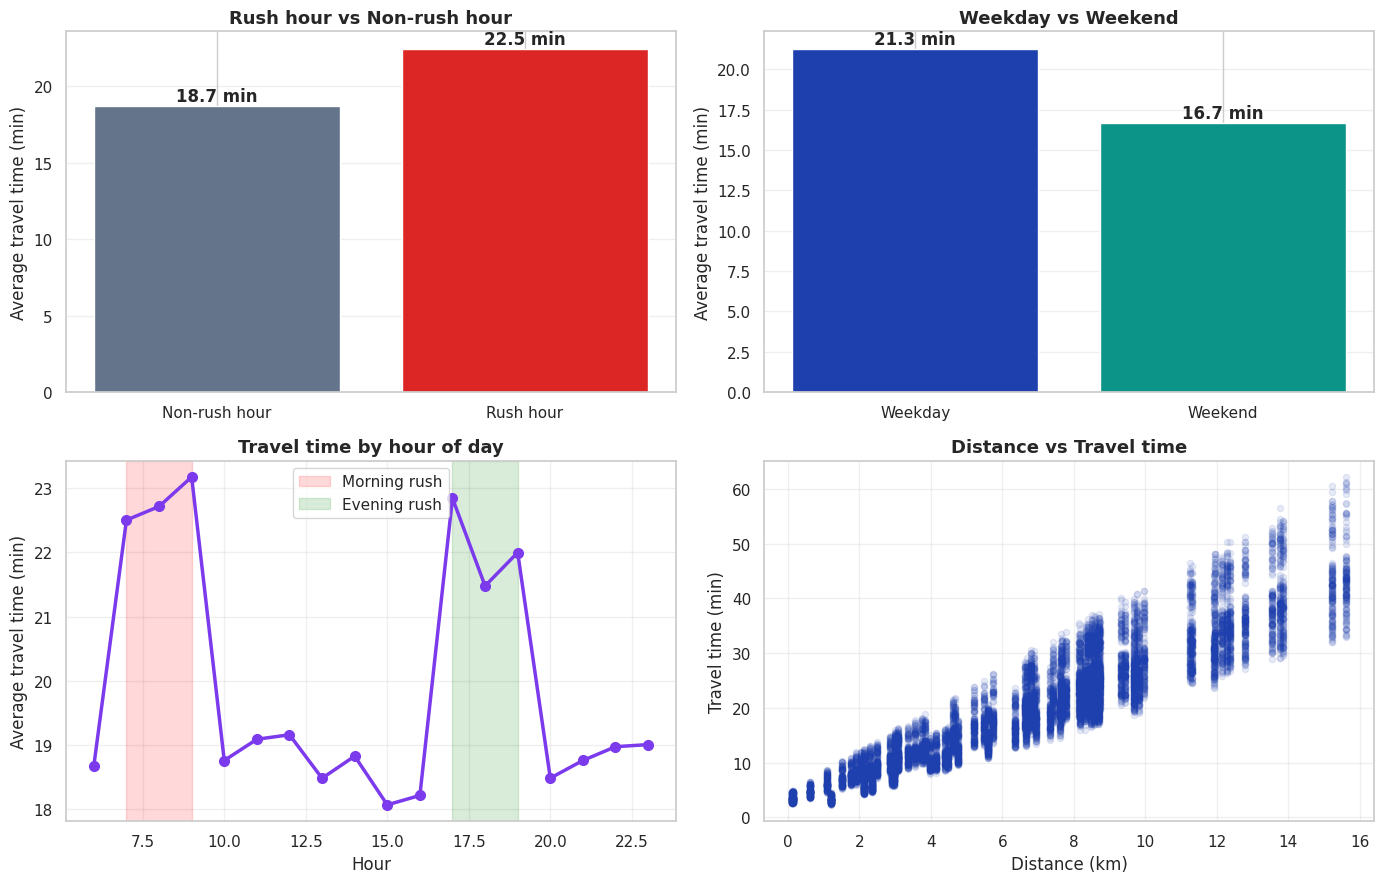


 Pattern มีจริงตามที่คาด:
- Rush hour เพิ่มเวลา ~20%
- Weekend เร็วกว่า weekday 22%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Rush hour vs non-rush
ax = axes[0, 0]
data_rush = df.groupby('is_rush_hour')['travel_time_min'].mean()
ax.bar(['Non-rush hour', 'Rush hour'], data_rush.values,
       color=['#64748B', '#DC2626'])
for i, v in enumerate(data_rush.values):
    ax.text(i, v + 0.3, f'{v:.1f} min', ha='center', fontweight='bold')
ax.set_title('Rush hour vs Non-rush hour', fontsize=13, fontweight='bold')
ax.set_ylabel('Average travel time (min)')
ax.grid(axis='y', alpha=0.3)

# 2. Weekday vs Weekend
ax = axes[0, 1]
data_week = df.groupby('is_weekend')['travel_time_min'].mean()
ax.bar(['Weekday', 'Weekend'], data_week.values,
       color=['#1E40AF', '#0D9488'])
for i, v in enumerate(data_week.values):
    ax.text(i, v + 0.3, f'{v:.1f} min', ha='center', fontweight='bold')
ax.set_title('Weekday vs Weekend', fontsize=13, fontweight='bold')
ax.set_ylabel('Average travel time (min)')
ax.grid(axis='y', alpha=0.3)

# 3. Hour of day pattern
ax = axes[1, 0]
hourly = df.groupby('hour')['travel_time_min'].mean()
ax.plot(hourly.index, hourly.values, 'o-', color='#7C3AED', linewidth=2.5, markersize=7)
ax.axvspan(7, 9, alpha=0.15, color='red', label='Morning rush')
ax.axvspan(17, 19, alpha=0.15, color='green', label='Evening rush')
ax.set_title('Travel time by hour of day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Average travel time (min)')
ax.legend()
ax.grid(alpha=0.3)

# 4. Distance vs travel time
ax = axes[1, 1]
ax.scatter(df['distance_km'], df['travel_time_min'], alpha=0.1, color='#1E40AF', s=20)
ax.set_title('Distance vs Travel time', fontsize=13, fontweight='bold')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Travel time (min)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Pattern มีจริงตามที่คาด:")
print(f"- Rush hour เพิ่มเวลา ~{(data_rush[True]/data_rush[False]-1)*100:.0f}%")
print(f"- Weekend เร็วกว่า weekday {(1-data_week[True]/data_week[False])*100:.0f}%")


---

## Section 3: Feature Engineering

### เตรียม features สำหรับ ML model

**Categorical features** ต้องแปลงเป็น numeric ด้วย one-hot encoding:
- origin, destination (station names)
- origin_line, dest_line

**Numerical features** ใช้ได้เลย:
- hour, day_of_week, month
- distance_km, num_interchanges

**Boolean features** แปลงเป็น 0/1:
- is_weekend, is_holiday, is_rainy_season, is_rush_hour


In [ ]:
# Feature engineering
df_ml = df.copy()

# Boolean -> int
for col in ['is_weekend', 'is_holiday', 'is_rainy_season', 'is_rush_hour']:
    df_ml[col] = df_ml[col].astype(int)

# One-hot encode stations และ lines
df_ml = pd.get_dummies(df_ml, columns=['origin', 'destination', 'origin_line', 'dest_line'],
                       drop_first=False)

# Drop date (เราใช้ day_of_week, month, is_holiday แทน)
df_ml = df_ml.drop(columns=['date'])

# Target
y = df_ml['travel_time_min']
X = df_ml.drop(columns=['travel_time_min'])

print(f"Features: {X.shape[1]} columns")
print(f"Samples: {X.shape[0]:,}")
print(f"\n Feature types:")
print(X.dtypes.value_counts())


Features: 45 columns
Samples: 14,620

 Feature types:
bool       36
int64       8
float64     1
Name: count, dtype: int64


---

## Section 4: Train 3 Models & Compare

### เทรน 3 models เปรียบเทียบกัน

1. **Linear Regression** (baseline) — เรียบง่าย ใช้เป็นจุดเปรียบเทียบ
2. **Random Forest** — ensemble ของ decision trees, จัดการ non-linear ได้ดี
3. **XGBoost** — gradient boosting, มักชนะ benchmark สำหรับ tabular data

### Metrics ที่ใช้วัด
- **MAE** (Mean Absolute Error) — เฉลี่ยผิดพลาดกี่นาที (ตีความง่าย)
- **RMSE** (Root Mean Squared Error) — ลงโทษ error ใหญ่ ๆ มาก
- **R²** — อธิบาย variance ได้กี่ % (ใกล้ 1 ยิ่งดี)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import time

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,} samples")
print(f"Test:  {len(X_test):,} samples\n")

# Train 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15,
                                            random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=7,
                                 learning_rate=0.1, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    print(f"🔄 Training {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'train_time': train_time,
        'predictions': y_pred,
    }
    print(f"MAE: {mae:.2f} min | RMSE: {rmse:.2f} min | R²: {r2:.4f} | time: {train_time:.1f}s\n")


Train: 11,696 samples
Test:  2,924 samples

🔄 Training Linear Regression...
MAE: 1.57 min | RMSE: 2.22 min | R²: 0.9556 | time: 0.0s

🔄 Training Random Forest...
MAE: 0.71 min | RMSE: 1.01 min | R²: 0.9909 | time: 5.1s

🔄 Training XGBoost...
MAE: 0.68 min | RMSE: 0.96 min | R²: 0.9917 | time: 0.9s



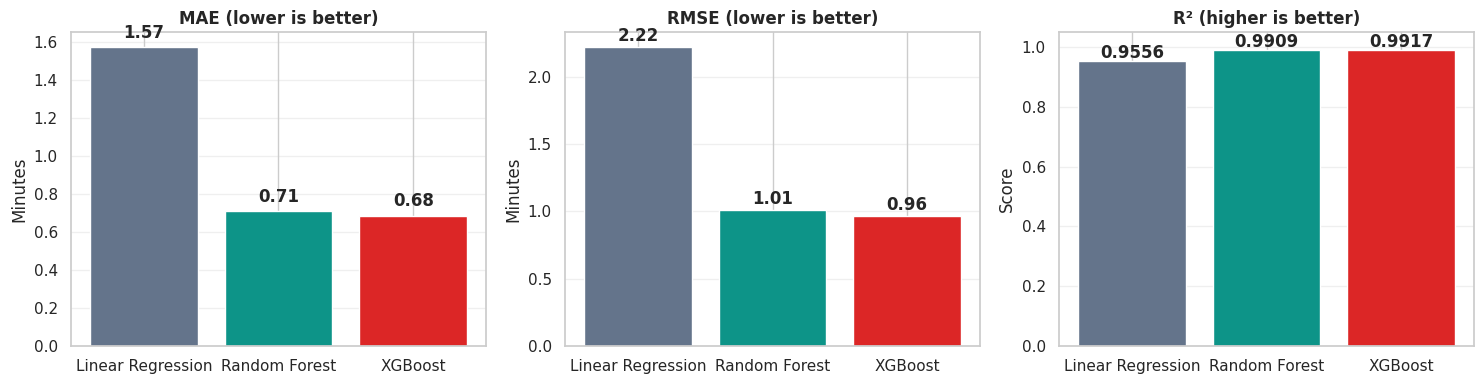


🏆 Best model: XGBoost
   MAE: 0.68 minutes (เฉลี่ยผิดพลาด ~1 นาที)
   R²: 0.9917 (อธิบาย variance ได้ 99.2%)


In [ ]:
# เปรียบเทียบ models ด้วยกราฟ
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_names = list(results.keys())
colors = ['#64748B', '#0D9488', '#DC2626']

# MAE
mae_values = [results[m]['mae'] for m in model_names]
axes[0].bar(model_names, mae_values, color=colors)
axes[0].set_title('MAE (lower is better)', fontweight='bold')
axes[0].set_ylabel('Minutes')
for i, v in enumerate(mae_values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# RMSE
rmse_values = [results[m]['rmse'] for m in model_names]
axes[1].bar(model_names, rmse_values, color=colors)
axes[1].set_title('RMSE (lower is better)', fontweight='bold')
axes[1].set_ylabel('Minutes')
for i, v in enumerate(rmse_values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# R²
r2_values = [results[m]['r2'] for m in model_names]
axes[2].bar(model_names, r2_values, color=colors)
axes[2].set_title('R² (higher is better)', fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1.05)
for i, v in enumerate(r2_values):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# หา best model
best_name = min(results.items(), key=lambda x: x[1]['mae'])[0]
print(f"\n🏆 Best model: {best_name}")
print(f"   MAE: {results[best_name]['mae']:.2f} minutes (เฉลี่ยผิดพลาด ~{results[best_name]['mae']:.0f} นาที)")
print(f"   R²: {results[best_name]['r2']:.4f} (อธิบาย variance ได้ {results[best_name]['r2']*100:.1f}%)")


### Prediction vs Actual plot

ดูว่า model ที่ดีที่สุดทำนายได้แม่นแค่ไหน ถ้า model สมบูรณ์แบบ ทุกจุดจะอยู่บนเส้น diagonal


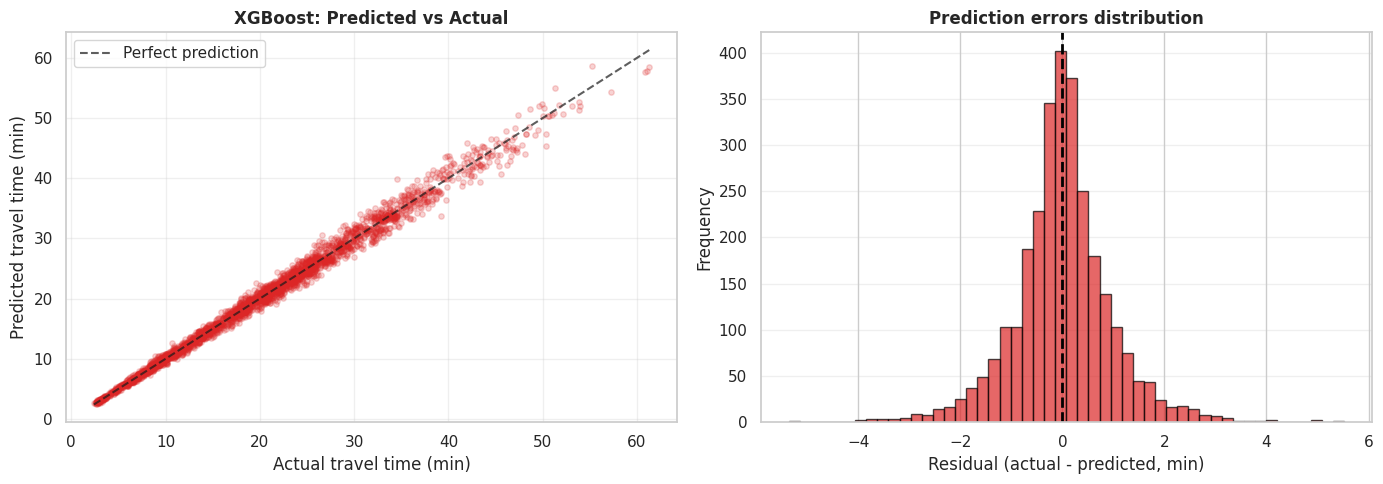


📊 Residual analysis:
   Mean error: -0.006 min (ใกล้ 0 = ไม่มี bias)
   Std error: 0.96 min


In [ ]:
best_model = results[best_name]['model']
y_pred = results[best_name]['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.2, color='#DC2626', s=15)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label='Perfect prediction')
axes[0].set_xlabel('Actual travel time (min)')
axes[0].set_ylabel('Predicted travel time (min)')
axes[0].set_title(f'{best_name}: Predicted vs Actual', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals histogram
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='#DC2626', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (actual - predicted, min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Prediction errors distribution', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Residual analysis:")
print(f"   Mean error: {residuals.mean():.3f} min (ใกล้ 0 = ไม่มี bias)")
print(f"   Std error: {residuals.std():.2f} min")


---

## Section 5: Feature Importance

### ดูว่า feature ไหนสำคัญที่สุด


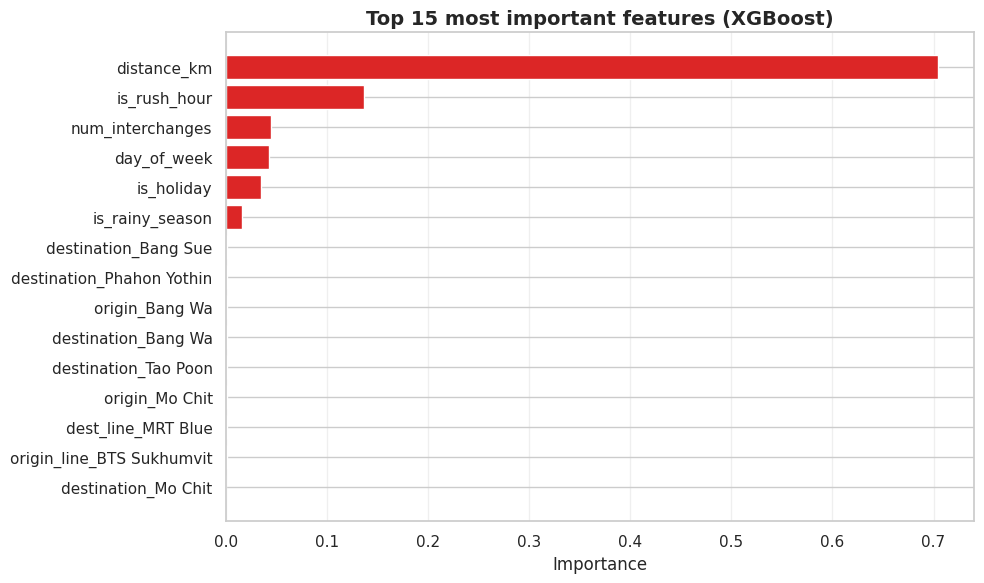


📌 Top 5 features:
   distance_km: 0.7048
   is_rush_hour: 0.1362
   num_interchanges: 0.0445
   day_of_week: 0.0428
   is_holiday: 0.0349


In [ ]:
# Feature importance จาก XGBoost หรือ Random Forest
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_,
    }).sort_values('importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
            color='#DC2626')
    ax.set_title(f'Top 15 most important features ({best_name})',
                 fontweight='bold', fontsize=14)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n📌 Top 5 features:")
    for i, row in importance_df.head(5).iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")
else:
    print("Linear Regression ไม่มี feature_importances_ (ใช้ coefficients แทน)")


---

## Section 6: Save Model

### บันทึก model ไว้ใช้งาน

1. **Model file** (`.pkl`) — model ที่ train เสร็จแล้ว
2. **Feature columns list**  เอาไว้ดูต้องเตรียม features อะไรตอน predict


In [ ]:
import joblib
import json

# Save model
joblib.dump(best_model, 'travel_time_model.pkl')
print(f"Model saved: travel_time_model.pkl")

# Save feature columns (สำคัญมาก เพราะตอน predict ต้องเรียงเหมือนตอน train)
feature_info = {
    'model_name': best_name,
    'features': X.columns.tolist(),
    'n_features': X.shape[1],
    'metrics': {
        'mae': float(results[best_name]['mae']),
        'rmse': float(results[best_name]['rmse']),
        'r2': float(results[best_name]['r2']),
    },
    'train_size': len(X_train),
    'test_size': len(X_test),
}

with open('travel_time_model_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)
print(f"✅ Feature info saved: travel_time_model_info.json")

# Download ไฟล์จาก Colab ลงเครื่อง
from google.colab import files
files.download('travel_time_model.pkl')
files.download('travel_time_model_info.json')


Model saved: travel_time_model.pkl
✅ Feature info saved: travel_time_model_info.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Upload to Hugging Face Hub



In [ ]:
from huggingface_hub import HfApi, login


login(token="YOUR_HF_TOKEN_HERE")

# Upload model
api = HfApi()
api.create_repo(repo_id="ChayakornP/bts-mrt-travel-time", exist_ok=True)
api.upload_file(
    path_or_fileobj="travel_time_model.pkl",
    path_in_repo="model.pkl",
    repo_id="ChayakornP/bts-mrt-travel-time",
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  travel_time_model.pkl       :  90%|########9 | 1.47MB / 1.64MB            

CommitInfo(commit_url='https://huggingface.co/ChayakornP/bts-mrt-travel-time/commit/bef03e6f5c78a1ec6703b4490eb9f04f0fdbe263', commit_message='Upload model.pkl with huggingface_hub', commit_description='', oid='bef03e6f5c78a1ec6703b4490eb9f04f0fdbe263', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ChayakornP/bts-mrt-travel-time', endpoint='https://huggingface.co', repo_type='model', repo_id='ChayakornP/bts-mrt-travel-time'), pr_revision=None, pr_num=None)

---

## Section 7: Example — ทดลองใช้ model ทำนาย

ลองใช้ model ทำนายเส้นทางจริง


In [17]:
def predict_travel_time(origin, destination, hour, date_str,
                          model=best_model, feature_cols=X.columns):
    """
    ทำนายเวลาเดินทางระหว่าง 2 สถานี

    Args:
        origin: ชื่อสถานีต้นทาง เช่น 'Siam'
        destination: ชื่อสถานีปลายทาง เช่น 'Mo Chit'
        hour: ชั่วโมง (0-23)
        date_str: วันที่ 'YYYY-MM-DD'

    Returns:
        predicted travel time (minutes)
    """
    date = pd.to_datetime(date_str)

    # หาข้อมูลสถานี
    origin_row = df_stations[df_stations['name'] == origin].iloc[0]
    dest_row = df_stations[df_stations['name'] == destination].iloc[0]

    # คำนวณ features
    distance_km = haversine(origin_row['lat'], origin_row['lng'],
                             dest_row['lat'], dest_row['lng'])
    num_interchanges = count_interchanges(origin_row['line'], dest_row['line'])

    is_rush = int((7 <= hour <= 9) or (17 <= hour <= 19))
    is_weekend = int(date.weekday() >= 5)
    is_rainy = int(date.month in [5,6,7,8,9,10])

    # สร้าง feature vector (ใส่ 0 ก่อน แล้วค่อยเติมค่า)
    feat = {col: 0 for col in feature_cols}
    feat['hour'] = hour
    feat['day_of_week'] = date.weekday()
    feat['month'] = date.month
    feat['is_weekend'] = is_weekend
    feat['is_holiday'] = 0  # simplified
    feat['is_rainy_season'] = is_rainy
    feat['is_rush_hour'] = is_rush
    feat['distance_km'] = distance_km
    feat['num_interchanges'] = num_interchanges

    # One-hot encoded columns
    for col in feature_cols:
        if col == f'origin_{origin}': feat[col] = 1
        if col == f'destination_{destination}': feat[col] = 1
        if col == f'origin_line_{origin_row["line"]}': feat[col] = 1
        if col == f'dest_line_{dest_row["line"]}': feat[col] = 1

    X_pred = pd.DataFrame([feat])[feature_cols]
    prediction = model.predict(X_pred)[0]

    return prediction


# ทดสอบเส้นทางต่างๆ
test_cases = [
    ('Siam', 'Mo Chit', 8, '2024-11-15', 'เช้าวันศุกร์ (rush hour)'),
    ('Siam', 'Mo Chit', 14, '2024-11-15', 'บ่ายวันศุกร์ (ปกติ)'),
    ('Siam', 'Mo Chit', 10, '2024-11-16', 'สายวันเสาร์'),
    ('Siam', 'Mo Chit', 18, '2024-08-15', 'เย็นวันพฤหัส (rush + ฤดูฝน)'),
    ('Asok', 'Silom', 8, '2024-11-15', 'เช้าวันศุกร์ ข้ามสาย'),
    ('Phrom Phong', 'On Nut', 22, '2024-12-24', 'ดึกวันคริสต์มาสอีฟ'),
]

print("🚇 Travel time predictions:\n")
print(f"{'Route':<30} {'Scenario':<35} {'Minutes':>10}")
print("=" * 80)
for origin, dest, hour, date, desc in test_cases:
    mins = predict_travel_time(origin, dest, hour, date)
    route = f'{origin} → {dest}'
    print(f"{route:<30} {desc:<35} {mins:>8.1f} min")


🚇 Travel time predictions:

Route                          Scenario                               Minutes
Siam → Mo Chit                 เช้าวันศุกร์ (rush hour)                21.4 min
Siam → Mo Chit                 บ่ายวันศุกร์ (ปกติ)                     17.1 min
Siam → Mo Chit                 สายวันเสาร์                             14.6 min
Siam → Mo Chit                 เย็นวันพฤหัส (rush + ฤดูฝน)             22.7 min
Asok → Silom                   เช้าวันศุกร์ ข้ามสาย                    12.7 min
Phrom Phong → On Nut           ดึกวันคริสต์มาสอีฟ                      10.9 min


---

## Summary

### What we built

✅ Custom ML model ทำนายเวลาเดินทาง BTS/MRT  
✅ เทรน 3 models เปรียบเทียบ (Linear, Random Forest, XGBoost)  
✅ Feature engineering ครบ (time, route, weather)  
✅ Save model พร้อม deploy  
✅ Example usage function พร้อมใช้งาน  

### Key techniques shown

- **Synthetic data generation** with real-world pattern rules
- **Feature engineering** (categorical encoding, boolean conversion)
- **Model comparison** with MAE, RMSE, R² metrics
- **Feature importance analysis**
- **Model persistence** with joblib

### Next steps (if time allows)

- Hyperparameter tuning ด้วย GridSearchCV หรือ Optuna
- Cross-validation แทน single train/test split
- เพิ่ม features ใหม่ เช่น วันหยุดนักขัตฤกษ์ครบทุกวัน, งาน event
- Deploy model เป็น FastAPI endpoint
- Integrate กับ Airflow pipeline หลัก

---

**Files generated:**
- `travel_time_model.pkl` — trained model
- `travel_time_model_info.json` — feature names + metrics
